In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(4)

In [ ]:
df = pd.read_csv('fashion-mnist_test.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


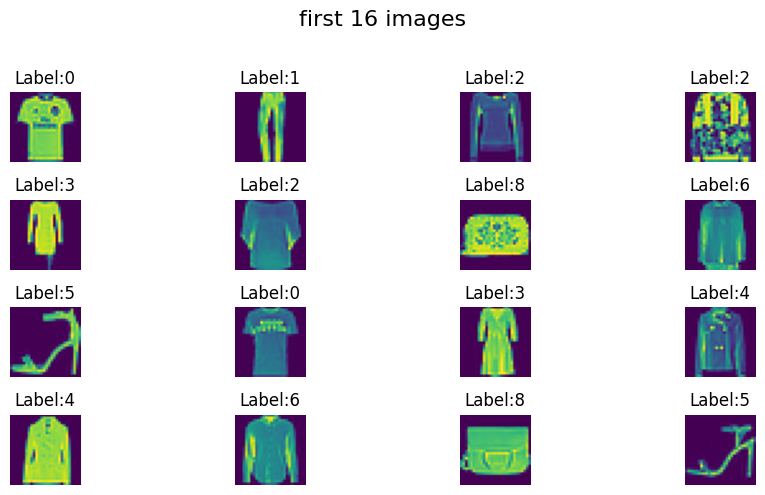

In [ ]:
fig,axes = plt.subplots(4,4,figsize=(10,5))
fig.suptitle("first 16 images", fontsize = 16)

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label:{df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [ ]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = features
    self.labels = labels

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [ ]:
train_dataset = CustomDataset(X_train,y_train)

In [ ]:
test_dataset = CustomDataset(X_test,y_test)

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [ ]:
class MyNN(nn.Module):

  def __init__(self,input_dim,output_dim,num_hidden_layers,neurons_per_layer):
    super().__init__()
    layers = []

    for i in range(num_hidden_layers):
        layers.append(nn.Linear(input_dim,neurons_per_layer))
        input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer,output_dim))

In [ ]:
def objective(trial):
  num_hidden_layers = trial.suggest_int('num_hidden_layers',1,5)
  neurons_per_layer = trial.suggest_int('neurons_per_layer',8,128,steps = 8)
  input_dim = 784
  output_dim = 10


In [ ]:
class MyNN(nn.Module):

  def __init__(self,num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.model(x)

In [ ]:
epochs = 100
learning_rate = 0.1

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = MyNN(X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=learning_rate)

Using device: cuda


In [ ]:
epochs = 100 # Ensure epochs is defined

for epoch in range(epochs):
  total_loss = 0.0
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    optimizer.zero_grad()
    outputs = model(batch_features)
    loss = criterion(outputs,batch_labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  avg_loss = total_loss / len(train_loader)
  print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/100], Loss: 1.1179
Epoch [2/100], Loss: 0.6517
Epoch [3/100], Loss: 0.5626
Epoch [4/100], Loss: 0.5009
Epoch [5/100], Loss: 0.4625
Epoch [6/100], Loss: 0.4329
Epoch [7/100], Loss: 0.4157
Epoch [8/100], Loss: 0.3985
Epoch [9/100], Loss: 0.3776
Epoch [10/100], Loss: 0.3629
Epoch [11/100], Loss: 0.3468
Epoch [12/100], Loss: 0.3289
Epoch [13/100], Loss: 0.3218
Epoch [14/100], Loss: 0.3056
Epoch [15/100], Loss: 0.3019
Epoch [16/100], Loss: 0.2880
Epoch [17/100], Loss: 0.2761
Epoch [18/100], Loss: 0.2706
Epoch [19/100], Loss: 0.2540
Epoch [20/100], Loss: 0.2517
Epoch [21/100], Loss: 0.2384
Epoch [22/100], Loss: 0.2347
Epoch [23/100], Loss: 0.2238
Epoch [24/100], Loss: 0.2157
Epoch [25/100], Loss: 0.2171
Epoch [26/100], Loss: 0.2244
Epoch [27/100], Loss: 0.2060
Epoch [28/100], Loss: 0.1979
Epoch [29/100], Loss: 0.1947
Epoch [30/100], Loss: 0.1847
Epoch [31/100], Loss: 0.1798
Epoch [32/100], Loss: 0.1726
Epoch [33/100], Loss: 0.1692
Epoch [34/100], Loss: 0.1649
Epoch [35/100], Loss: 0

In [ ]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
import torch

total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)
    _, predicted = torch.max(outputs.data,1)
    total += batch_labels.size(0)
    correct += (predicted == batch_labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.75%
